# Data Visualization — Hotel Cancellation Data

## Goal

Turn the tabular findings from the EDA Notebook into clearly labeled figures that
communicate the predictive signal in the booking data.

This notebook reads the cleaned/encoded output of `data-processing.ipynb`.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/processed_data.csv")

# from_onehot + label decoding reused from the EDA Notebook
def from_onehot(frame, prefix, baseline):
    s = pd.Series(baseline, index=frame.index)
    for c in [c for c in frame.columns if c.startswith(prefix)]:
        s = s.mask(frame[c] == 1, c[len(prefix):])
    return s

df["hotel_label"] = df["hotel"].map({1: "City Hotel", 0: "Resort Hotel"})
df["deposit_type"] = from_onehot(df, "deposit_type_", "No Deposit")
df["customer_type"] = from_onehot(df, "customer_type_", "Contract")
df["distribution_channel"] = from_onehot(df, "distribution_channel_", "Corporate")
df["repeated_guest"] = df["is_repeated_guest"].map({0: "No", 1: "Yes"})
df["arrival_month"] = from_onehot(df, "arrival_date_month_", "April")

categorical_cols = ["hotel_label", "deposit_type", "customer_type",
                    "distribution_channel", "repeated_guest"]

# overall_rate from the EDA Notebook, reused as the baseline line in the plots below
overall_rate = df["is_canceled"].mean()
print(f"Rows: {len(df):,}   Overall cancellation rate: {overall_rate:.1%}")

Rows: 119,209   Overall cancellation rate: 37.1%


## 2. Target Variable Balance

Check how (im)balanced the target is — this drives the evaluation choices later (ROC-AUC / PR-AUC over raw accuracy).

Stayed (0): 62.9 %
Cancelled (1): 37.1 %


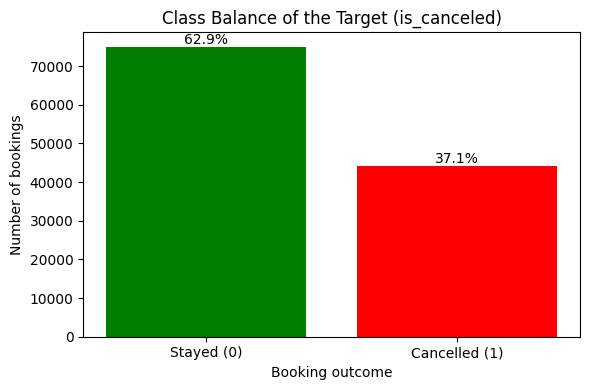

In [3]:
counts = df["is_canceled"].value_counts().sort_index()

pct = counts / len(df) * 100
print("Stayed (0):", round(pct[0], 1), "%")
print("Cancelled (1):", round(pct[1], 1), "%")

# Plot canceled vs. not canceled
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Stayed (0)", "Cancelled (1)"], counts.values, color=["green", "red"])

ax.text(0, counts.values[0], f"{pct[0]:.1f}%", ha="center", va="bottom")
ax.text(1, counts.values[1], f"{pct[1]:.1f}%", ha="center", va="bottom")

ax.set_title("Class Balance of the Target (is_canceled)")
ax.set_xlabel("Booking outcome")
ax.set_ylabel("Number of bookings")
plt.tight_layout()
plt.show()

The figure above shows the split between bookings that were kept and those that were cancelled. Around 37% of the bookings were cancelled, so the classes are somewhat imbalanced but not severely. The cancelled bookings are the ones we actually care about predicting, so accuracy is a misleading metric here: a model that just guesses "not cancelled" every time would already hit about 63%. Because of that I'll focus on ROC-AUC and PR-AUC, which look at how well the model ranks the minority class rather than just how many it gets right overall.

## 3. Distribution Analysis (patterns & skewness)

Histograms of the key numeric features to expose skew and long tails.

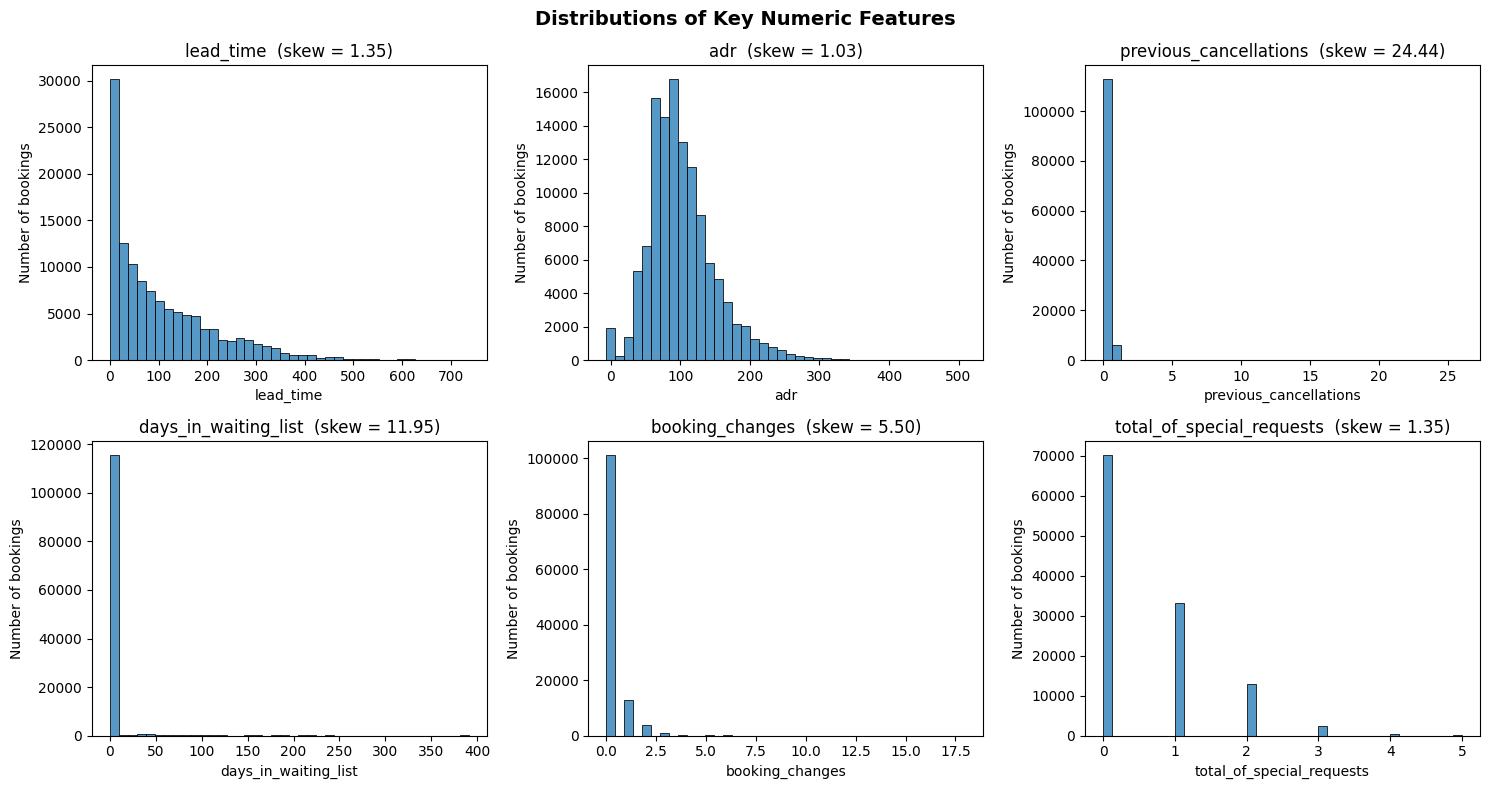

In [4]:
# same numeric features and skew check used in the EDA Notebook, now plotted as histograms
dist_cols = ["lead_time", "adr", "previous_cancellations",
             "days_in_waiting_list", "booking_changes", "total_of_special_requests"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), dist_cols):                            
    sns.histplot(df[col], bins=40,  ax=ax)
    ax.set_title(f"{col}  (skew = {df[col].skew():.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of bookings")

fig.suptitle("Distributions of Key Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

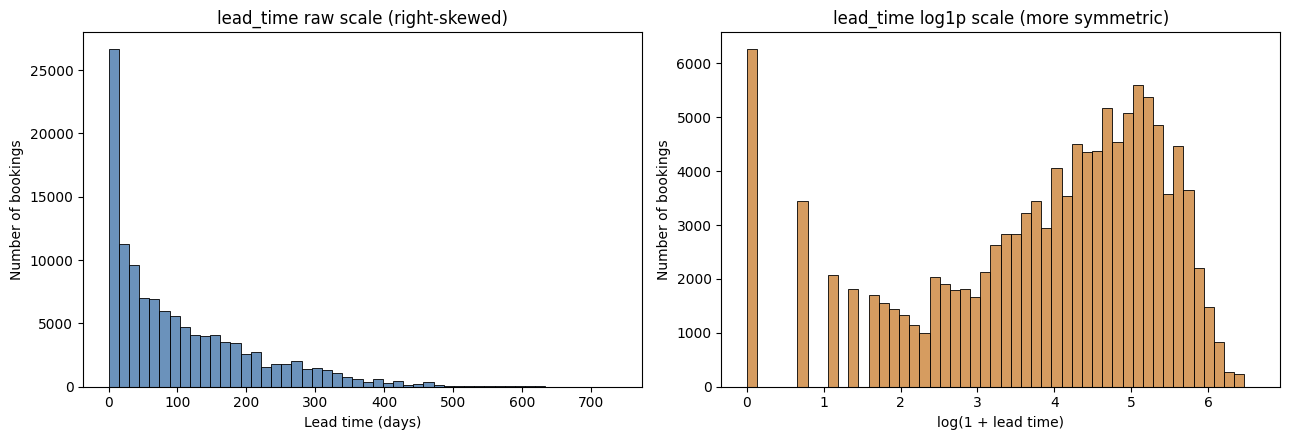

In [5]:
# lead_time is strongly right-skewed. Compare raw vs log scale
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["lead_time"], bins=50, color="#3A6EA5", ax=axes[0])
axes[0].set_title("lead_time raw scale (right-skewed)")
axes[0].set_xlabel("Lead time (days)")
axes[0].set_ylabel("Number of bookings")

sns.histplot(df["lead_time_log"], bins=50, color="#C97B2B", ax=axes[1])
axes[1].set_title("lead_time log1p scale (more symmetric)")
axes[1].set_xlabel("log(1 + lead time)")
axes[1].set_ylabel("Number of bookings")

plt.tight_layout()
plt.show()

The figures above show the distribution of each key numeric feature, plus a raw-vs-log comparison for lead_time. The numeric features are mostly right-skewed. `previous_cancellations`, `days_in_waiting_list`, and `booking_changes` are zero for almost every booking with a few rare large values, while lead_time and adr are continuous but have long right tails.

## 4. Lead Time vs. Cancellation

`lead_time` is the strongest numeric predictor in the EDA. Visualized in two
ways: a box plot of the distribution split by outcome, and the cancellation
rate across lead-time buckets.

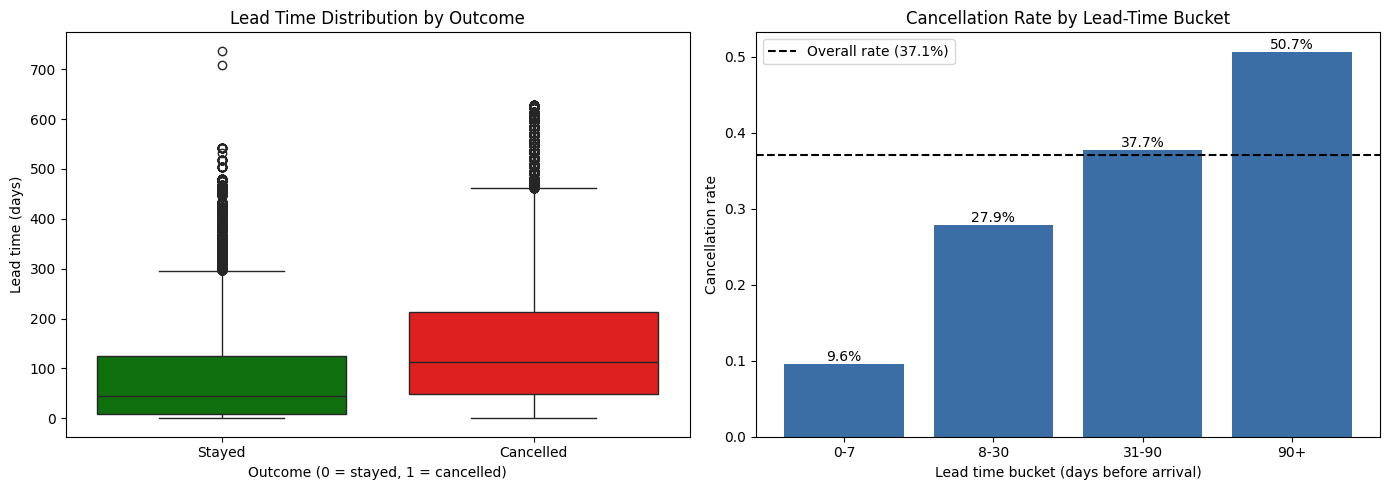

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="is_canceled", y="lead_time",
            hue="is_canceled", palette={0: "green", 1: "red"}, legend=False, ax=axes[0])
axes[0].set_title("Lead Time Distribution by Outcome")
axes[0].set_xlabel("Outcome (0 = stayed, 1 = cancelled)")
axes[0].set_ylabel("Lead time (days)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Stayed", "Cancelled"])

# lead-time buckets + bucket_rate copied from the EDA Notebook
bins = [-1, 7, 30, 90, np.inf]
labels = ["0-7", "8-30", "31-90", "90+"]
bucket_rate = df.groupby(pd.cut(df["lead_time"], bins=bins, labels=labels),
                         observed=True)["is_canceled"].mean()
bars = axes[1].bar(bucket_rate.index.astype(str), bucket_rate.values, color="#3A6EA5")
for b, v in zip(bars, bucket_rate.values):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f"{v:.1%}", ha="center", va="bottom")
axes[1].axhline(overall_rate, color="black", linestyle="--",
                label=f"Overall rate ({overall_rate:.1%})")
axes[1].set_title("Cancellation Rate by Lead-Time Bucket")
axes[1].set_xlabel("Lead time bucket (days before arrival)")
axes[1].set_ylabel("Cancellation rate")
axes[1].legend()

plt.tight_layout()
plt.show()

The figure above shows lead time split by outcome and the cancellation rate across lead-time buckets. Cancelled bookings have a higher median lead time than those that are honoured. Risk increases monotonically from ~10% for last-minute bookings (0–7 days) to over 50% for bookings made 90+ days out. Lead time is a reliable early risk signal available the moment a booking is made.

## 5. Cancellation Rate by Categorical Feature

For each categorical feature, I compared the cancellation rate of every level
against the overall baseline.

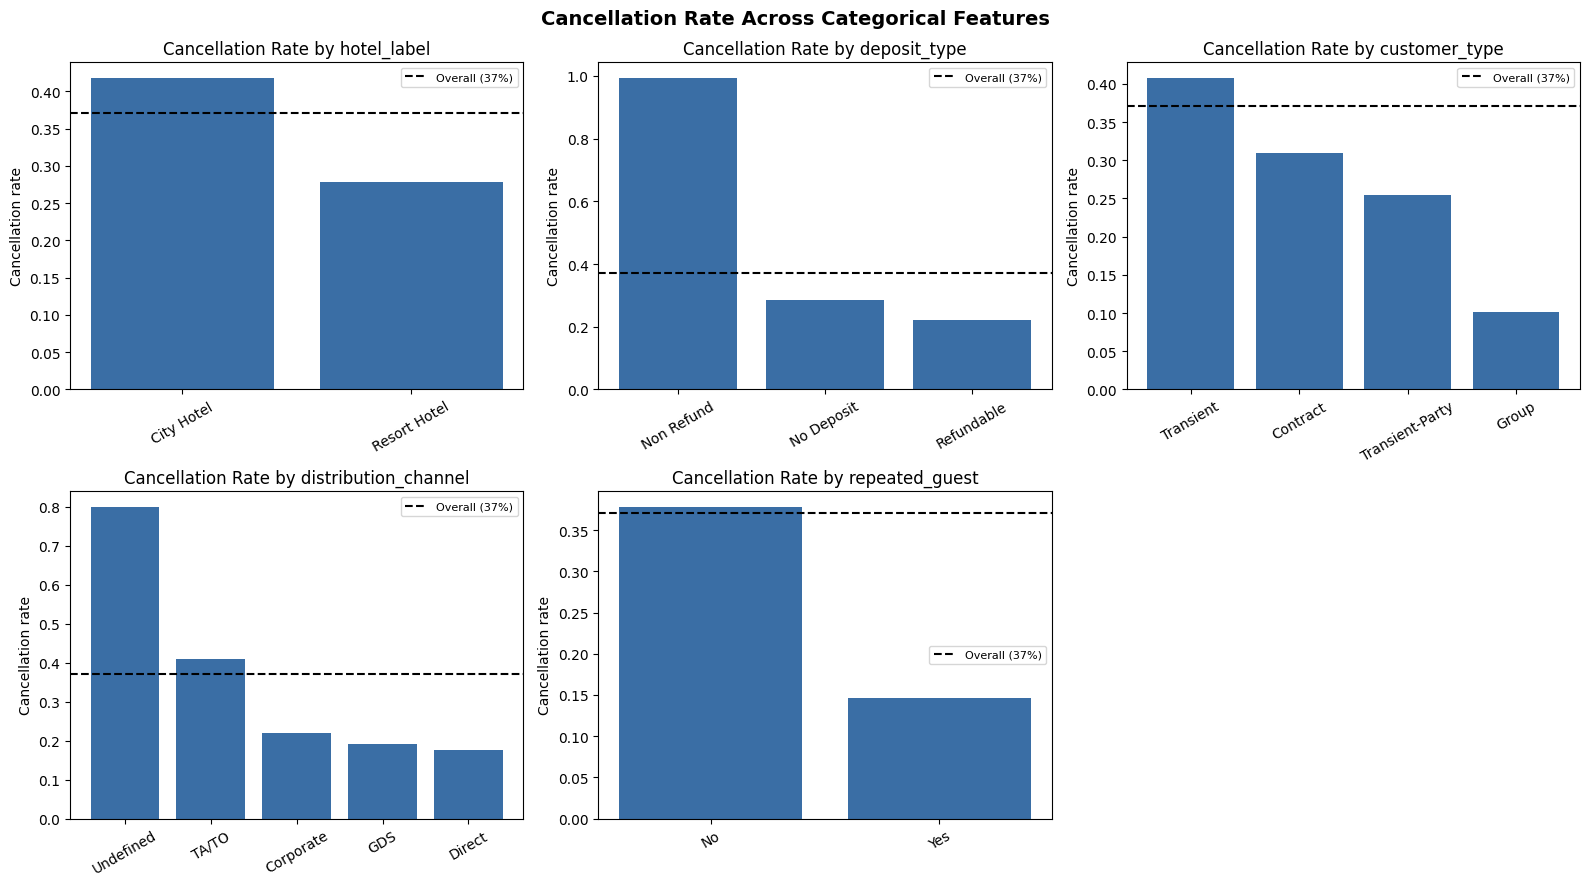

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, col in zip(axes, categorical_cols):
    # per-category cancellation rate, same groupby as the EDA Notebook
    rate = df.groupby(col)["is_canceled"].mean().sort_values(ascending=False)
    ax.bar(rate.index.astype(str), rate.values, color="#3A6EA5")
    ax.axhline(overall_rate, color="black", linestyle="--",
               label=f"Overall ({overall_rate:.0%})")
    ax.set_title(f"Cancellation Rate by {col}")
    ax.set_ylabel("Cancellation rate")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

# hide the unused 6th panel
axes[-1].axis("off")
fig.suptitle("Cancellation Rate Across Categorical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

The figure above shows the cancellation rate for each level of the categorical features compared to the overall baseline. The most surprising result is that non-refundable deposits cancel about 99% of the time, why are 99% of non-refundable bookings canceled? I confirmed it against the raw data, so it is not an encoding bug; it is likely no-shows recorded as cancellations or mislabeled source data. Either way it is a leakage risk worth treating with caution, since a feature that matches the target ~99% of the time can dominate a model without being a real booking-time signal. Aside from that, City Hotels cancel more than Resort Hotels, Transient customers more than Groups, TA/TO channel more than Direct, and repeat guests cancel far less than first-timers. The `distribution_channel` panel also shows a tiny `Undefined` level cancelling ~80% of the time, but it covers only a handful of bookings with a missing channel, so I treat it as a low-volume data-quality artifact rather than a trustworthy signal. These map naturally onto one-hot features the models can exploit.

## 6. Correlation Analysis

How numeric features relate to the target and to each other.

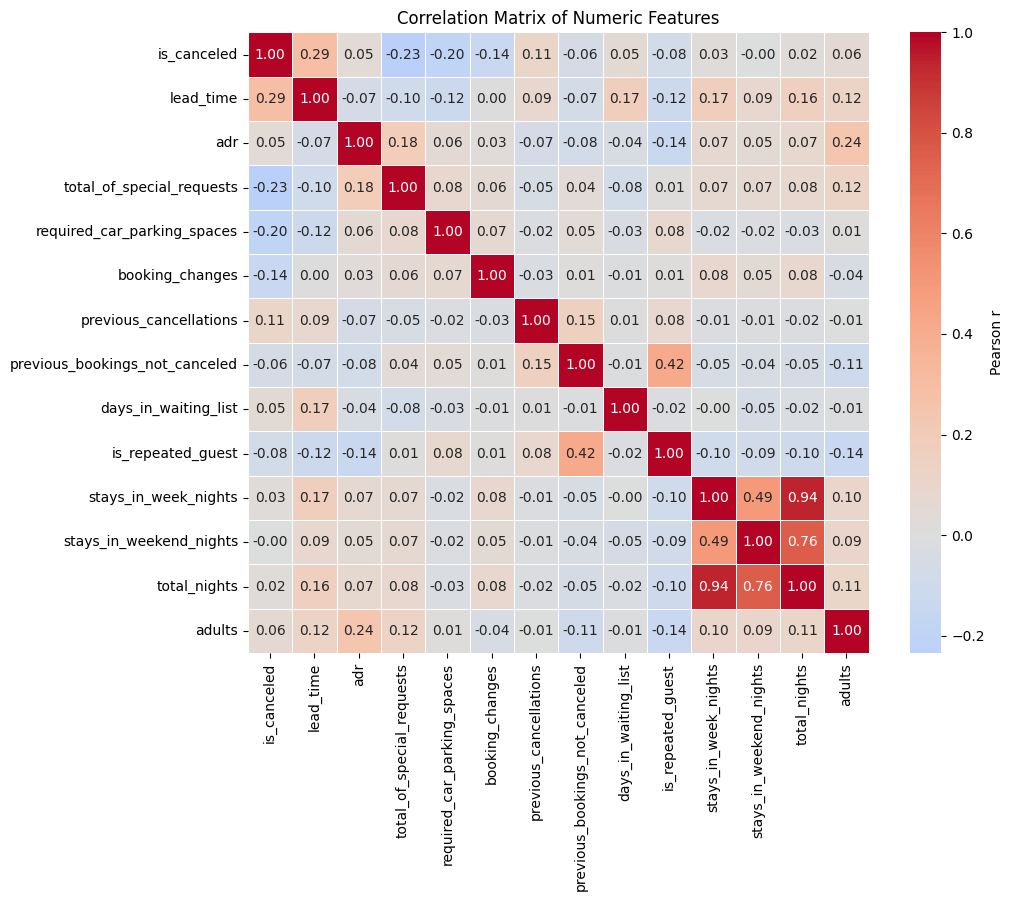

In [8]:
# heat_cols + corr matrix copied from the EDA Notebook (printed there, plotted here)
heat_cols = [
    "is_canceled", "lead_time", "adr", "total_of_special_requests",
    "required_car_parking_spaces", "booking_changes", "previous_cancellations",
    "previous_bookings_not_canceled", "days_in_waiting_list", "is_repeated_guest",
    "stays_in_week_nights", "stays_in_weekend_nights", "total_nights", "adults",
]
corr = df[heat_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

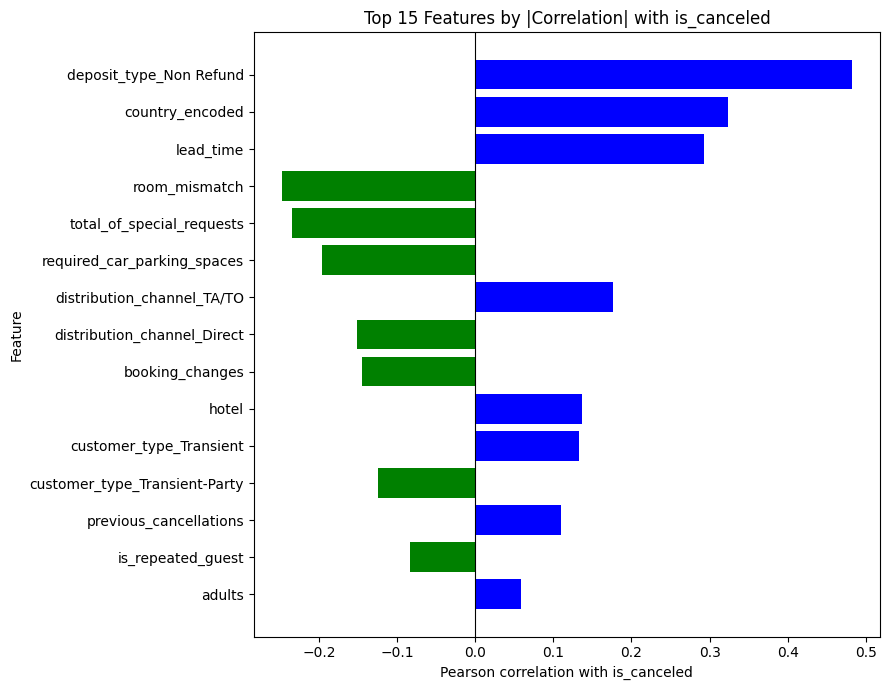

In [9]:
# target_corr / top-15 ranking copied from the EDA Notebook
target_corr = (
    df.select_dtypes("number")
      .drop(columns=["is_canceled", "lead_time_log", "adr_log"])
      .corrwith(df["is_canceled"])
)
top = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(15)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["blue" if v > 0 else "green" for v in top.values]
ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 15 Features by |Correlation| with is_canceled")
ax.set_xlabel("Pearson correlation with is_canceled")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

The figure above shows how the numeric features correlate with each other and with the target. No single numeric feature is collinear enough to be redundant except by construction (`total_nights` = week + weekend nights). Against the target, `deposit_type_Non Refund` (+0.48), `country_encoded` (+0.32) and `lead_time` (+0.29) push risk up, while engagement signals — `total_of_special_requests`, `required_car_parking_spaces`, `room_mismatch`, `booking_changes` — pull it down. The red/green split shows risk-raising vs. risk-lowering features at a glance.

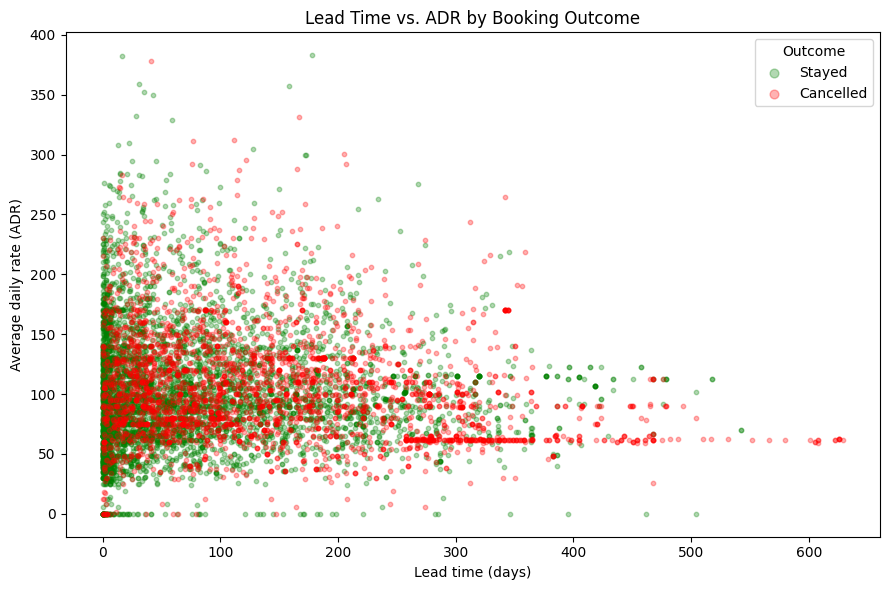

In [10]:
# scatter of the two main continuous features, colored by outcome (sampled to keep the plot readable)
sample = df.sample(n=8000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
for outcome, color, lbl in [(0, "green", "Stayed"), (1, "red", "Cancelled")]:
    sub = sample[sample["is_canceled"] == outcome]
    ax.scatter(sub["lead_time"], sub["adr"], s=10, alpha=0.3,
               color=color, label=lbl)
ax.set_title("Lead Time vs. ADR by Booking Outcome")
ax.set_xlabel("Lead time (days)")
ax.set_ylabel("Average daily rate (ADR)")
ax.legend(title="Outcome", markerscale=2)
plt.tight_layout()
plt.show()

The scatter above plots the two main continuous features, `lead_time` and `adr`, against each other on a random sample of bookings, colored by outcome. Cancelled bookings (red) spread noticeably further to the right along the lead-time axis, reinforcing that long lead times carry more risk, while stayed bookings (green) cluster at short lead times. ADR shows no clean vertical separation, cancellations occur across the full price range, which matches its near-zero linear correlation.

## 7. Time-Based Patterns

Cancellation rate and booking volume by arrival month, in calendar order.

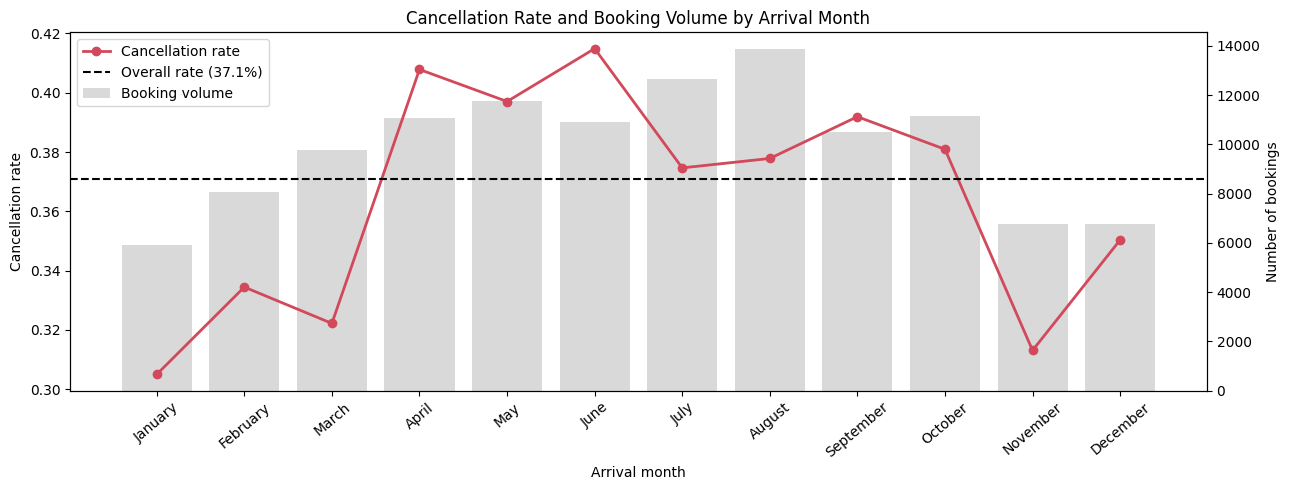

In [11]:
# month_order + month_rate copied from the EDA Notebook
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
month_rate = df.groupby("arrival_month")["is_canceled"].mean().reindex(month_order)
month_vol = df["arrival_month"].value_counts().reindex(month_order)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax2.bar(month_order, month_vol.values, color="#D9D9D9", label="Booking volume")
ax1.plot(month_order, month_rate.values, color="#D1495B", marker="o",
         linewidth=2, label="Cancellation rate")
ax1.axhline(overall_rate, color="black", linestyle="--",
            label=f"Overall rate ({overall_rate:.1%})")

ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)
ax1.set_title("Cancellation Rate and Booking Volume by Arrival Month")
ax1.set_xlabel("Arrival month")
ax1.set_ylabel("Cancellation rate")
ax2.set_ylabel("Number of bookings")
ax1.tick_params(axis="x", rotation=40)

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc="upper left")
plt.tight_layout()
plt.show()

The figure above shows the cancellation rate and booking volume by arrival month. Cancellation rate peaks in spring/early summer (April–June, ~40%) and dips in winter (January, November, ~31%). Booking volume is highest in the busy summer months, so absolute cancellations concentrate there even when the rate is similar. There is a usable seasonal component, though it is weaker than the deposit/lead-time signals.

## 8. Feature Importance (Mutual Information)

Mutual information captures non-linear dependence between each feature and the
target, complementing the linear correlation view above.

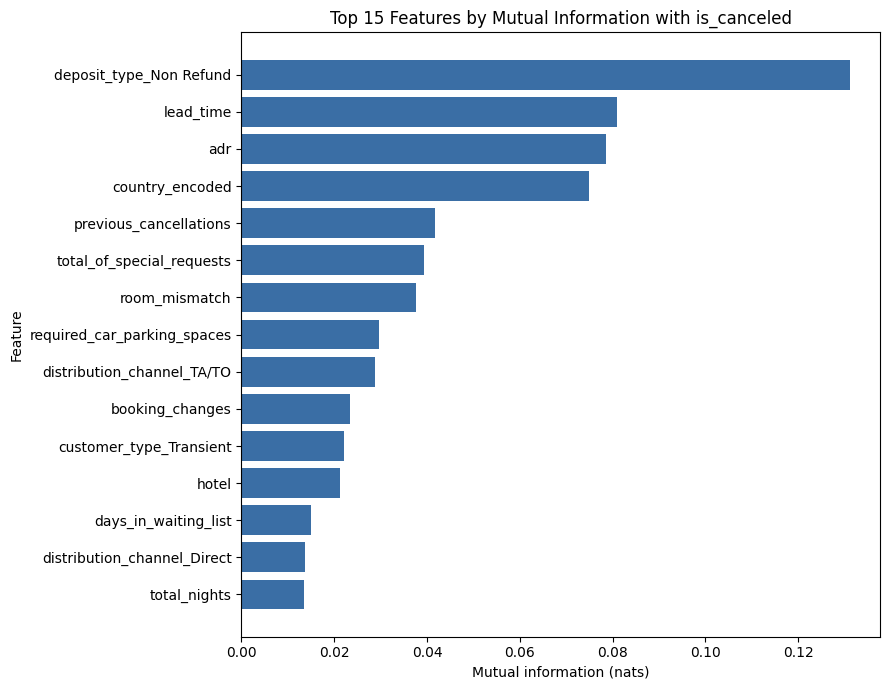

In [12]:
from sklearn.feature_selection import mutual_info_classif

# mutual information setup (feature_cols, X/y, mi_classif) copied from the EDA Notebook
feature_cols = [c for c in df.select_dtypes("number").columns
                if c not in ("is_canceled", "lead_time_log", "adr_log")]
X = df[feature_cols].fillna(0)
y = df["is_canceled"]

mi_scores = mutual_info_classif(X, y, random_state=42)
mi = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(mi.index[::-1], mi.values[::-1], color="#3A6EA5")
ax.set_title("Top 15 Features by Mutual Information with is_canceled")
ax.set_xlabel("Mutual information (nats)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

The figure above shows the top features ranked by mutual information with the target. Mutual information agrees with the correlation ranking on the leaders — `deposit_type_Non Refund`, `lead_time`, `adr`, and `country_encoded` carry the most signal — but it surfaces `adr` more strongly, hinting at a non-linear price effect that linear correlation understates. These features are the priority inputs for the baseline and boosted models.

## 9. Visualization Summary

- **Target:** ~37% cancellation rate is a moderate imbalance so use ROC-AUC / PR-AUC.
- **Strongest risk drivers:** non-refundable deposit, long lead time, country, TA/TO channel.
- **Strongest protective signals:** special requests, parking, booking changes, repeat-guest status.
- **Seasonality:** spring/early-summer arrivals cancel more; winter cancels less.
- **Skew:** most numeric features are right-skewed so log transforms help linear models.